In [1]:
print('hello')

hello


In [22]:
import numpy as np
import pandas as pd

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns',None)

In [6]:
df = pd.read_csv('Bike_Share_Demand.csv')
df.head()

,date,year,month,day_of_week,hour,is_weekend,season,weather,temperature_c,humidity,windspeed_kmh,air_quality_index,holiday,working_day,fuel_price,traffic_index,app_active_users,promotion_active,city_zone,near_metro_station,special_event,bike_station_capacity,bike_demand
0,07-11-2025,2025,11,4,18,0,Autumn,Mist,23.6,82,18.1,48,0,1,115.96,50.7,24211,0,Residential,1,0,304,668
1,17-04-2023,2023,4,0,19,0,Spring,Heavy Rain,27.2,88,29.5,102,0,1,112.67,72.6,33078,0,Tourist Area,1,0,281,596
2,07-04-2023,2023,4,4,7,0,Spring,Clear,30.7,71,16.5,74,0,1,91.07,75.5,39685,0,Residential,1,0,410,869
3,24-04-2023,2023,4,0,19,0,Spring,Light Rain,21.1,89,18.0,74,1,0,103.66,71.4,24987,1,Tourist Area,1,0,489,591
4,30-09-2024,2024,9,0,19,0,Monsoon,Light Rain,27.3,93,28.9,94,0,1,94.57,59.6,38148,0,Residential,0,0,228,260


In [21]:
df.shape

(10000, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   10000 non-null  object 
 1   year                   10000 non-null  int64  
 2   month                  10000 non-null  int64  
 3   day_of_week            10000 non-null  int64  
 4   hour                   10000 non-null  int64  
 5   is_weekend             10000 non-null  int64  
 6   season                 10000 non-null  object 
 7   weather                10000 non-null  object 
 8   temperature_c          10000 non-null  float64
 9   humidity               10000 non-null  int64  
 10  windspeed_kmh          10000 non-null  float64
 11  air_quality_index      10000 non-null  int64  
 12  holiday                10000 non-null  int64  
 13  working_day            10000 non-null  int64  
 14  fuel_price             10000 non-null  float64
 15  tra

In [8]:
df.isnull().sum()

date                     0
year                     0
month                    0
day_of_week              0
hour                     0
is_weekend               0
season                   0
weather                  0
temperature_c            0
humidity                 0
windspeed_kmh            0
air_quality_index        0
holiday                  0
working_day              0
fuel_price               0
traffic_index            0
app_active_users         0
promotion_active         0
city_zone                0
near_metro_station       0
special_event            0
bike_station_capacity    0
bike_demand              0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['date'] = pd.to_datetime(df['date'],format="%d-%m-%Y")

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   10000 non-null  datetime64[ns]
 1   year                   10000 non-null  int64         
 2   month                  10000 non-null  int64         
 3   day_of_week            10000 non-null  int64         
 4   hour                   10000 non-null  int64         
 5   is_weekend             10000 non-null  int64         
 6   season                 10000 non-null  object        
 7   weather                10000 non-null  object        
 8   temperature_c          10000 non-null  float64       
 9   humidity               10000 non-null  int64         
 10  windspeed_kmh          10000 non-null  float64       
 11  air_quality_index      10000 non-null  int64         
 12  holiday                10000 non-null  int64         
 13  wo

In [46]:
num_col = df.select_dtypes(include=[np.number])
num_col.describe().T

,count,mean,std,min,25%,50%,75%,max
year,10000.0,2024.003700,0.818507,2023.00,2023.0000,2024.00,2025.000,2025.00
month,10000.0,6.505300,3.441650,1.00,4.0000,6.00,10.000,12.00
day_of_week,10000.0,2.996900,2.000972,0.00,1.0000,3.00,5.000,6.00
hour,10000.0,13.447300,5.190445,5.00,9.0000,13.00,18.000,22.00
is_weekend,10000.0,0.286200,0.452007,0.00,0.0000,0.00,1.000,1.00
temperature_c,10000.0,26.951340,8.703151,2.10,20.1000,27.20,33.900,51.90
humidity,10000.0,61.810100,17.879116,30.00,46.0000,64.00,77.000,95.00
windspeed_kmh,10000.0,14.804710,5.716420,5.00,10.3000,14.70,19.025,30.00
air_quality_index,10000.0,120.504200,39.743920,30.00,93.0000,121.00,148.000,267.00
holiday,10000.0,0.057300,0.232427,0.00,0.0000,0.00,0.000,1.00


In [19]:
df.corr(numeric_only=True)['bike_demand'].sort_values(ascending=False)

bike_demand              1.000000
working_day              0.288614
app_active_users         0.185442
fuel_price               0.171933
traffic_index            0.169070
near_metro_station       0.167639
promotion_active         0.142919
special_event            0.080761
bike_station_capacity    0.051428
hour                     0.001995
year                    -0.001505
air_quality_index       -0.078090
month                   -0.084212
holiday                 -0.085848
temperature_c           -0.206903
day_of_week             -0.217207
is_weekend              -0.267345
windspeed_kmh           -0.284339
humidity                -0.345844
Name: bike_demand, dtype: float64

In [38]:
cat_cols = df.select_dtypes(include=['object'])
cat_cols.head(2)

,season,weather,city_zone
0,Autumn,Mist,Residential
1,Spring,Heavy Rain,Tourist Area


In [41]:
for col in cat_cols:
    print(df[col].value_counts())

season
Spring     2594
Summer     2509
Winter     2483
Autumn     1626
Monsoon     788
Name: count, dtype: int64
weather
Clear         4539
Cloudy        1999
Mist          1515
Light Rain    1505
Heavy Rain     442
Name: count, dtype: int64
city_zone
Residential          3103
Commercial           2460
Business District    1940
University Area      1495
Tourist Area         1002
Name: count, dtype: int64


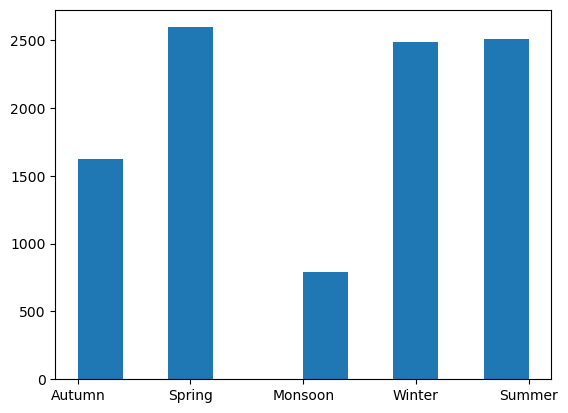

In [45]:
plt.hist(df['season']);